# 📝 과제 — 나만의 Tavily 검색 Agent 만들기

**제출 전 체크리스트**
- [ ] 모든 셀을 처음부터 다시 실행(`Kernel → Restart & Run All`)해서 오류 없음 확인
- [ ] API 키가 코드에 직접 노출되지 않음 (`.env` 파일 사용)
- [ ] `stream()` 출력 결과가 셀에 남아 있음
- [ ] 자연어 질문 최소 3개 실행 결과 포함

---

> 이 파일에서 `# TODO` 주석이 있는 셀을 찾아 직접 채우면 된다.  
> 환경 설정과 LangGraph 기본 구조는 미리 작성되어 있다.


---
## STEP 1. 패키지 설치


In [1]:
%pip install -qU \
    langgraph \
    langchain \
    langchain-openai \
    langchain-community \
    tavily-python \
    python-dotenv

Note: you may need to restart the kernel to use updated packages.


---
## STEP 2. API 키 설정

`.env` 파일을 프로젝트 루트에 만들고 아래 내용을 채운다.

```
OPENAI_API_KEY=sk-...
TAVILY_API_KEY=tvly-...
```

Tavily API 키 발급: https://app.tavily.com

> API 키를 코드에 직접 쓰지 않는다. 반드시 `.env` 파일을 사용한다.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

# 키 등록 확인
assert os.getenv('OPENAI_API_KEY'),  '❌ OPENAI_API_KEY 없음 — .env 파일을 확인하세요'
assert os.getenv('TAVILY_API_KEY'),  '❌ TAVILY_API_KEY 없음 — .env 파일을 확인하세요'

print('✅ API 키 확인 완료')
print(f'   OPENAI  키 앞 8자리: {os.getenv("OPENAI_API_KEY")[:8]}...')
print(f'   TAVILY  키 앞 8자리: {os.getenv("TAVILY_API_KEY")[:8]}...')

✅ API 키 확인 완료
   OPENAI  키 앞 8자리: sk-svcac...
   TAVILY  키 앞 8자리: tvly-dev...


---
## STEP 3. LLM 초기화


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

# 연결 확인
response = llm.invoke('안녕! 한 문장으로 자기소개 해줘.')
print(response.content)

c:\Users\minso\anaconda3\envs\session4\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


안녕하세요! 저는 다양한 주제에 대해 대화하고 정보를 제공하는 AI 언어 모델입니다.


---
## STEP 4. LangGraph 기본 구조

아래 코드는 수업에서 배운 기본 Agent 구조다. 그대로 사용한다.  
다음 단계에서 Tool과 프롬프트를 직접 추가하면 된다.


In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# State 정의 — 메시지 목록을 들고 다닌다
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# Conditional Edge — Tool 호출 여부로 분기
def should_continue(state: AgentState) -> str:
    if state['messages'][-1].tool_calls:
        return 'use_tool'
    return 'finish'

print('✅ LangGraph 기본 구조 준비 완료')

✅ LangGraph 기본 구조 준비 완료


---
## STEP 5. ✏️ Tool 정의 — 직접 작성

Tavily 검색 Tool을 정의한다.  
**description이 핵심이다.** LLM은 description을 보고 언제 이 Tool을 쓸지 결정한다.

필요하다면 Tavily 외에 다른 Tool을 추가해도 좋다.  
(예: 날짜 조회, 계산 등)


In [5]:
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

# ── Tavily 검색 Tool ────────────────────────────────────
# TODO: max_results 값을 조정하고,
#       아래 @tool 함수의 docstring(description)을 직접 작성한다.
#       어떤 상황에서 이 Tool을 써야 하는지 구체적으로 설명할수록 좋다.

tavily_search = TavilySearchResults(max_results=5)

@tool
def search_web(query: str) -> str:
    """TODO: 이 Tool이 언제, 어떤 상황에서 사용되어야 하는지 설명을 작성하세요.
    예시: 어떤 종류의 질문에 써야 하는가, 어떤 종류의 질문에 쓰면 안 되는가

    When to use: Searching major news, market conditions, macroeconomic issues
    When not to use: Math calculations, coding, translation, general explanations that don't require current web information

    """
    results = tavily_search.invoke({
            "query": query,
            "topic": "news",
            "time_range": "day",
            "search_depth": "advanced",
            "include_domains": [
                "reuters.com",
                "bloomberg.com",
                "cnbc.com",
                "ft.com",
                "wsj.com",
                "marketwatch.com",
                "finance.yahoo.com"
            ]
        })
    if not results:
        return '검색 결과가 없습니다.'
    # 결과를 하나의 문자열로 합친다

    if isinstance(results, dict):
        results = results.get("results", [])

    if not results:
        return "검색 결과가 없습니다."

    formatted = []
    for i, r in enumerate(results, 1):
        title = r.get("title", "제목 없음")
        url = r.get("url", "URL 없음")
        content = r.get("content", "요약 없음")
        formatted.append(
            f"[뉴스 {i}]\n"
            f"제목: {title}\n"
            f"URL: {url}\n"
            f"요약: {content}"
        )

    return "\n\n".join(formatted)

# TODO (선택): 추가 Tool이 필요하면 여기에 작성한다
@tool
def get_market_snapshot(query: str = "US market snapshot today S&P 500 Nasdaq Dow Jones Treasury yield dollar index VIX oil gold bitcoin") -> str:
    """
    When to use: Retrieving the latest state of major market indexes, current information on stocks, yields, volatility, dollar, crypto
    When not to use: Searching past historical data, general knowledge and definitions, 
    """
    results = tavily_search.invoke({
            "query": query,
            "topic": "finance",
            "search_depth": "advanced",
            "max_results": 5,
            "include_domains": [
                "finance.yahoo.com",
                "marketwatch.com",
                "cnbc.com",
                "reuters.com",
                "bloomberg.com",
                "wsj.com",
                "investing.com"
            ]
        })
    
    if not results:
        return "시장 스냅샷 결과가 없습니다."

    if isinstance(results, dict):
        results = results.get("results", [])

    if not results:
        return "시장 스냅샷 결과가 없습니다."
    
    formatted = []
    for i, r in enumerate(results, 1):
        title = r.get("title", "제목 없음")
        url = r.get("url", "URL 없음")
        content = r.get("content", "요약 없음")
        formatted.append(
            f"[Market Snapshot {i}]\n"
            f"Title: {title}\n"
            f"URL: {url}\n"
            f"Summary: {content}"
        )

    return "\n\n".join(formatted)

@tool
def get_ohlcv(query: str = "SPY OHLCV daily price recent 30 days Yahoo Finance MarketWatch") -> str:
    """
    When to use: recent open, high, low, close, and volume related information,
    inspect recent price trend or volatility for an index, ETF, or stock
    When not to use: asking for general news or macro headlines
    """

    results = tavily_search.invoke({
            "query": query,
            "topic": "finance",
            "search_depth": "advanced",
            "max_results": 5,
            "include_domains": [
                "finance.yahoo.com",
                "marketwatch.com",
                "investing.com",
                "reuters.com",
                "cnbc.com"
            ]
        })
    
    if not results:
        return "OHLCV 결과가 없습니다."

    if isinstance(results, dict):
        results = results.get("results", [])

    if not results:
        return "OHLCV 결과가 없습니다."

    formatted = []
    for i, r in enumerate(results, 1):
        title = r.get("title", "제목 없음")
        url = r.get("url", "URL 없음")
        content = r.get("content", "요약 없음")
        formatted.append(
            f"[OHLCV {i}]\n"
            f"Title: {title}\n"
            f"URL: {url}\n"
            f"Summary: {content}"
        )

    return "\n\n".join(formatted)


@tool
def get_cross_asset_regime(query: str = "cross asset market signals today equities yields dollar VIX oil gold bitcoin risk on risk off") -> str:
    """
    When to use: relationships between equities, yields, dollar, etc, 
    macro context before making a prediction
    When not to use: single stock or narrow topic, when cross asset analysis is not needed
    """

    results = tavily_search.invoke({
            "query": query,
            "topic": "finance",
            "search_depth": "advanced",
            "max_results": 5,
            "include_domains": [
                "reuters.com",
                "bloomberg.com",
                "cnbc.com",
                "marketwatch.com",
                "finance.yahoo.com",
                "investing.com"
            ]
        })


    if not results:
        return "Cross-asset regime 결과가 없습니다."

    if isinstance(results, dict):
        results = results.get("results", [])

    if not results:
        return "Cross-asset regime 결과가 없습니다."

    formatted = []
    for i, r in enumerate(results, 1):
        formatted.append(
            f"[Regime {i}]\n"
            f"Title: {r.get('title', '제목 없음')}\n"
            f"URL: {r.get('url', 'URL 없음')}\n"
            f"Summary: {r.get('content', '요약 없음')}"
        )

    return "\n\n".join(formatted)




# 사용할 Tool 목록
tools = [search_web, get_market_snapshot, get_ohlcv, get_cross_asset_regime]  # TODO: 추가 Tool이 있으면 여기에 넣는다

# Tool 확인
print('등록된 Tool 목록:')
for t in tools:
    print(f'  - {t.name}: {t.description[:60]}...')

등록된 Tool 목록:
  - search_web: TODO: 이 Tool이 언제, 어떤 상황에서 사용되어야 하는지 설명을 작성하세요.
예시: 어떤 종류의 질문...
  - get_market_snapshot: When to use: Retrieving the latest state of major market ind...
  - get_ohlcv: When to use: recent open, high, low, close, and volume relat...
  - get_cross_asset_regime: When to use: relationships between equities, yields, dollar,...


C:\Users\minso\AppData\Local\Temp\ipykernel_45640\3609471155.py:9: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=5)


**Tool이 잘 동작하는지 직접 호출해서 확인해보자.**


In [6]:
# TODO: 직접 검색어를 넣어서 Tool이 잘 동작하는지 확인한다
# result = search_web.invoke('TODO: 검색어를 입력하세요')
# print(result[:500])  # 결과가 길면 앞 500자만 출력

result = search_web.invoke('geopolitics US stock market today')
print(result[:500])

result = get_market_snapshot.invoke('S&P 500 Nasdaq Dow VIX dollar today')
print(result[:500])



[뉴스 1]
제목: How Geopolitics Is Reshaping the US Stock Market And What ...
URL: https://www.investing.com/analysis/how-geopolitics-is-reshaping-the-us-stock-market-and-what-comes-next-200677279
요약: CrowdStrike-Daily Chart

## What Comes Next for Markets

Geopolitics is likely to remain a dominant theme in the coming years.

Several scenarios could shape the next phase of the market:

### Scenario 1: Controlled Tensions

### Scenario 2: Escalation

### Scenario 3: De-escalation

## What Investors S
[Market Snapshot 1]
Title: CBOE Volatility Index (^VIX) Charts, Data & News - Yahoo Finance
URL: https://finance.yahoo.com/quote/%5EVIX/
Summary: Wall Street Fear Index Slides Ahead of Trump Address

### Wall Street Fear Index Slides Ahead of Trump Address

Market Volatility Is Spiking. Here's Exactly What Long-Term Investors Should Do.

### Market Volatility Is Spiking. Here's Exactly What Long-Term Investors Should Do.

Almost everything is going wrong for markets right now

### Almost everyt

In [7]:
result = get_ohlcv.invoke("SPY daily OHLCV last 30 days")
print(result[:500])

result = get_cross_asset_regime.invoke("cross asset market signals equities yields dollar VIX oil gold today risk on risk off")
print(result[:500])

[OHLCV 1]
Title: SPY - Stock History & Analysis
URL: https://marketmentor.app/pages/SPY_history.html
Summary: | Date | Open | High | Low | Close | Volume |
 ---  ---  --- |
| 2025-12-31 | $687.14 | $687.36 | $681.71 | $681.92 | 74,048,064 |
| 2025-12-30 | $687.45 | $688.55 | $686.58 | $687.01 | 47,143,499 |
| 2025-12-29 | $687.54 | $689.20 | $686.07 | $687.85 | 62,500,773 |
| 2025-12-26 | $690.64 | $691.66 | $689.27 | $690.31 | 41,669,457 |
| 2025-12-24 | $687.95 | $690.83 | $687.80 | $690.38 | 
[Regime 1]
Title: Cross-Asset Sentiment Deteriorates, Opportunity Forms - LinkedIn
URL: https://www.linkedin.com/posts/branthammer_investing-markets-sentiment-activity-7438298629938880512-pSHF
Summary: • Sector rotation (energy > growth)
Cross-asset message
• Inflation pressure ↑
• Financial conditions tightening
• Policy path harder
• Risk appetite deteriorating
👉 This is not random weakness
It is a coordinated tightening signal
Equities (internal warning)
• Nasdaq < Dow
• Semis / AI weak
• En

---
## STEP 6. ✏️ 시스템 프롬프트 & Agent 조립 — 직접 작성

시스템 프롬프트로 Agent의 역할과 동작 방식을 정의한다.  
어떤 주제의 Agent인지, 어떤 스타일로 답변해야 하는지를 적는다.


In [8]:
# TODO: 아래 system_prompt를 내 Agent 주제에 맞게 수정한다
SYSTEM_PROMPT = """
You are a financial market analysis agent.

Your job is to help the user understand short-term market conditions by using available tools to gather:
- recent major news,
- current market snapshot information,
- recent OHLCV or price trend related information,
- cross asset regime signals.

Behavior rules:
- If the user asks about current market conditions, recent news, short-term market outlook or anything that requires up-to-date information, use the available tools before answering.
- Prefer using tools when the question depends on recent or real time information.
- Do not guess current events or market conditions without searching.
- Use the tools to collect relevant evidence first then answer based on the gathered information.
- If the available information is insufficient or unclear, say so clearly instead of making up a confident answer.
- Focus on short term market interpretation and not long term investing advice.

Answer style:
- Be clear, structured and concise.
- Summarize the most important findings first.
- When relevant explain the main drivers of the market move.
- If useful organize the answer into:
  1. Recent news
  2. Market snapshot
  3. Cross asset signals
  4. Short term interpretation

If the user asks something unrelated to current market analysis answer normally without unnecessary tool use.
"""

# ── Agent 노드 ────────────────────────────────────────
llm_with_tools = llm.bind_tools(tools)

def call_llm(state: AgentState) -> dict:
    # 시스템 프롬프트를 메시지 맨 앞에 붙여서 LLM에 전달
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

# ── 그래프 조립 ────────────────────────────────────────
graph = StateGraph(AgentState)

graph.add_node('call_llm',      call_llm)
graph.add_node('execute_tools', ToolNode(tools))

graph.add_edge(START, 'call_llm')
graph.add_conditional_edges(
    'call_llm',
    should_continue,
    {'use_tool': 'execute_tools', 'finish': END}
)
graph.add_edge('execute_tools', 'call_llm')

app = graph.compile()
print('✅ Agent 조립 완료')

✅ Agent 조립 완료


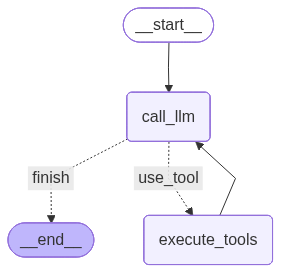

In [9]:
# 그래프 구조 확인
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

---
## STEP 7. ✏️ 실행 & 결과 확인 — 직접 작성

`stream()`으로 실행해서 **어떤 Tool이 어떤 순서로 호출됐는지** 흐름을 확인한다.  
최소 3개의 질문을 실행해야 한다.


### 실행 흐름 출력 함수

아래 함수를 사용하면 각 노드의 실행 흐름을 보기 좋게 출력할 수 있다.


In [10]:
from langchain_core.messages import ToolMessage

def run_agent(question: str):
    """질문을 실행하고 흐름과 최종 답변을 출력한다."""
    print("\n" + "=" * 60)
    print(f'Question: {question}')
    print('='*60)

    final_answer = ''

    for chunk in app.stream(
        {'messages': [HumanMessage(content=question)]},
        config={'recursion_limit': 25}
    ):
        for node_name, update in chunk.items():
            for msg in update.get('messages', []):
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    for tc in msg.tool_calls:
                        print(f'  🔍 Tool Call: {tc["name"]}({list(tc["args"].values())})')
                elif isinstance(msg, ToolMessage):
                    print(f'  📥 Tool Results: {msg.content[:80]}...')
                elif hasattr(msg, 'content') and msg.content:
                    final_answer = msg.content

    print(f'\n💬 Final Answer:')
    print(final_answer)

print('실행 함수 준비 완료')

실행 함수 준비 완료


### 질문 1


In [11]:
# TODO: 내 Agent 주제에 맞는 질문을 작성한다
#       반드시 실시간 정보가 필요한 질문이어야 한다 (Tavily가 필요한 이유)

run_agent("What is the current short term outlook for the US stock market?")


Question: What is the current short term outlook for the US stock market?
  🔍 Tool Call: search_web(['current US stock market news October 2023'])
  🔍 Tool Call: get_market_snapshot([])
  🔍 Tool Call: get_cross_asset_regime([])
  📥 Tool Results: [뉴스 1]
제목: U.S. Equities Market Attributes October 2023 | S&P Dow Jones Indices
...
  📥 Tool Results: [Market Snapshot 1]
Title: United States Stock Market Index - Quote - Chart - Tr...
  📥 Tool Results: [Regime 1]
Title: Saxo Market Compass - 7 April 2026
URL: https://www.home.saxo/...

💬 Final Answer:
### Current Short-Term Outlook for the US Stock Market

#### 1. Recent News
- **Market Performance**: The S&P 500 has declined by 2.20% in October, continuing a downward trend that began in September (-4.87%) and August (-1.77%). This marks a potential third consecutive month of losses, the longest streak since the pandemic began in 2020. (Source: S&P Dow Jones Indices)
- **Market Rally**: Recent news indicates a rally in US stock futures, driv

### 질문 2


In [12]:
run_agent("Summarize today's major market moving news and explain whether the market looks bullish or bearish.")


Question: Summarize today's major market moving news and explain whether the market looks bullish or bearish.
  🔍 Tool Call: search_web(['major market news today'])
  🔍 Tool Call: get_market_snapshot([])
  📥 Tool Results: [뉴스 1]
제목: Stock Market Today: Futures Soar as Trump Agrees to 2-Week Ceasefire ...
  📥 Tool Results: [Market Snapshot 1]
Title: United States Stock Market Index - Quote - Chart - Tr...

💬 Final Answer:
### Recent Major Market Moving News
1. **US-Iran Ceasefire Agreement**: A significant ceasefire agreement between the US, Iran, and Israel has been reached, allowing for a two-week truce and the reopening of the Strait of Hormuz. This has led to a surge in stock futures, with Dow futures rising by approximately 2.5% as markets anticipate a relief rally.
2. **Oil Price Drop**: Following the ceasefire, oil prices have fallen below $100 per barrel, which is contributing to positive sentiment in the stock market.
3. **Delta Air Lines Earnings**: Delta reported strong Q1 r

### 질문 3


In [13]:
run_agent("Based on recent news and market conditions, how might the S&P 500 move in the short term?")


Question: Based on recent news and market conditions, how might the S&P 500 move in the short term?
  🔍 Tool Call: search_web(['recent news S&P 500 October 2023'])
  🔍 Tool Call: get_market_snapshot(['S&P 500 market snapshot today'])
  🔍 Tool Call: get_cross_asset_regime(['cross asset market signals today equities yields dollar VIX oil gold bitcoin risk on risk off'])
  📥 Tool Results: [뉴스 1]
제목: S&P 500 Earnings Season Update: October 27, 2023
URL: https://insight...
  📥 Tool Results: [Market Snapshot 1]
Title: S&P 500 INDEX TODAY | INX LIVE TICKER - Markets Insid...
  📥 Tool Results: [Regime 1]
Title: Market Pulse: US Indices Rise Amid Global Volatility - LinkedI...

💬 Final Answer:
### Recent News
1. **Earnings Season Update**: As of October 27, 2023, eight out of eleven sectors in the S&P 500 are reporting year-over-year earnings growth, particularly in Communication Services, Consumer Discretionary, and Financials. However, sectors like Energy, Materials, and Health Care are seei

### (선택) 추가 질문

더 실험해보고 싶은 질문이 있으면 자유롭게 추가한다.


In [14]:
run_agent("Based on recent price trend, momentum, and market conditions, what is the short-term outlook for SPY?")


Question: Based on recent price trend, momentum, and market conditions, what is the short-term outlook for SPY?
  🔍 Tool Call: get_ohlcv(['SPY OHLCV daily price recent 30 days Yahoo Finance MarketWatch'])
  🔍 Tool Call: get_market_snapshot(['US market snapshot today S&P 500'])
  📥 Tool Results: [OHLCV 1]
Title: SPDR S&P 500 ETF (SPY) Stock Historical Prices & Data
URL: http...
  📥 Tool Results: [Market Snapshot 1]
Title: S&P 500 INDEX TODAY | INX LIVE TICKER - Markets Insid...
  🔍 Tool Call: get_cross_asset_regime(['cross asset market signals today equities yields dollar VIX oil gold bitcoin risk on risk off'])
  📥 Tool Results: [Regime 1]
Title: Market Pulse: US Indices Rise Amid Global Volatility - LinkedI...

💬 Final Answer:
### Short-Term Outlook for SPY (SPDR S&P 500 ETF)

#### 1. Recent News
- **Geopolitical Tensions**: Recent developments in the Middle East, particularly a ceasefire, have led to a temporary relief rally in U.S. equities, including SPY. However, the market remai